In [251]:
import  pandas as pd   #dataframes for working with tabular data
import numpy  as np  # numerical operations

#visulization
import matplotlib.pyplot as plt 
import seaborn as sns

#scikit learn  machine learning 
# Machine preprocessing 
from sklearn.model_selection import train_test_split   # split data into train/test sets
from sklearn.preprocessing import StandardScaler  # standardize numerical features / columns
from sklearn.preprocessing import LabelEncoder  # Encode categorical columns


#machine learning Model 
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 




# Machine Learning Evaluation

from sklearn.metrics import (accuracy_score, 
                               precision_score, 
                               recall_score, 
                               f1_score, 
                               confusion_matrix,
                               classification_report, 
                               roc_auc_score,
                               roc_curve)

#Setting
import warnings
warnings.filterwarnings('ignore')

sns.set_style ('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

#Set random seed for reproducility

RANDOM_STATE = 42

print("All libraries imported successfully!")

All libraries imported successfully!


In [252]:
## loading the dataset
nova_pay = "nova_pay_combined.xlsx"
df = pd.read_excel(nova_pay)

print("Data downloaded successfully")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("===== Data loaded successfully =====")

Data downloaded successfully
Shape: 11400 rows x 26 columns
===== Data loaded successfully =====


In [142]:
df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [253]:
print(df["timestamp"].head(150))

0      2022-10-03 18:40:59.468549+00:00
1      2022-10-03 20:39:38.468549+00:00
2      2022-10-03 23:02:43.468549+00:00
3      2022-10-04 01:08:53.468549+00:00
4      2022-10-04 09:35:03.468549+00:00
                     ...               
145    2022-10-20 07:12:35.468549+00:00
146    2022-10-20 15:29:20.468549+00:00
147    2022-10-20 16:02:19.468549+00:00
148    2022-10-20 16:05:21.468549+00:00
149    2022-10-20 17:42:39.468549+00:00
Name: timestamp, Length: 150, dtype: object


In [254]:
df.describe()

,amount_src,amount_usd,fee,exchange_rate_src_to_dest,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,11400.000000,11095.000000,11105.000000,11400.000000,11400.000000,11400.000000,11105.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000
mean,438.715927,452.022083,100.309441,167.540397,0.396726,393.793158,0.653681,0.048509,0.267134,0.458333,0.723509,0.045501,0.087456
std,1379.151759,1403.973062,958.128504,382.023827,0.270507,342.348393,0.273012,0.256194,0.142983,1.524494,1.958390,0.084942,0.282515
min,-9997.160000,7.230000,-1.000000,0.592000,0.004000,1.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,90.667500,92.465000,2.380000,1.000000,0.209000,147.000000,0.515000,0.000000,0.169000,0.000000,0.000000,0.000000,0.000000
50%,158.980000,163.480000,3.500000,7.142857,0.325000,298.000000,0.658000,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,294.785000,302.190000,5.550000,73.529412,0.487000,661.000000,0.894000,0.000000,0.391000,0.000000,0.000000,0.050000,0.000000
max,11942.890000,12498.570000,9999.990000,1388.888889,1.200000,1095.000000,0.999000,2.000000,0.900000,8.000000,11.000000,0.250000,1.000000


In [255]:
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

#### converting my  datetimestamp to date time to allow python recognise it as datetime imtead of plain text

In [256]:
#convert timestamp 
df["timestamp"] = pd.to_datetime(df["timestamp"],errors="coerce")

## convert currency_src to float
df["amount_src"] = pd.to_numeric(df["amount_src"],errors="coerce")
    

##### features engeering from datetime

In [257]:
df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month
df["day"] = df["timestamp"].dt.day
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek # o-monday,6-sunday
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)


In [258]:
#### by defualt python sometimes dont sure all columns..

In [259]:
pd.set_option('display.max_columns', None)

df.head()


,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,year,month,day,hour,day_of_week,is_weekend
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0,2022.0,10.0,3.0,18.0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0,2022.0,10.0,3.0,20.0,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0,2022.0,10.0,3.0,23.0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0,2022.0,10.0,4.0,1.0,1.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0,2022.0,10.0,4.0,9.0,1.0,0


In [260]:
numerical_columns = df.select_dtypes(include="number")
print(len(numerical_columns.columns))

19


 #### checking the skewness of my data as this will inform my choice of decison a long this project

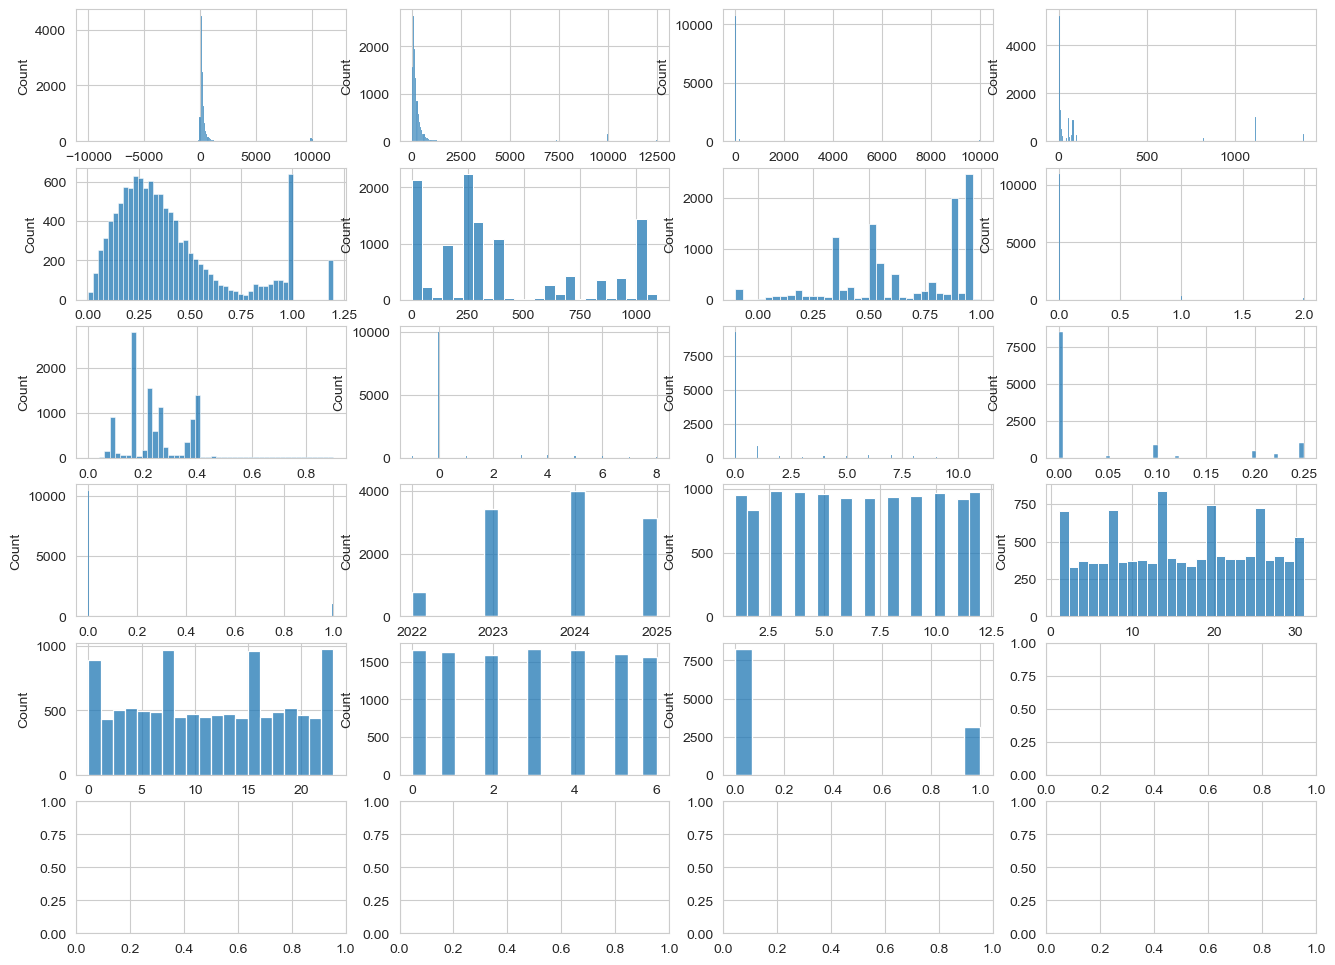

In [261]:
fig, ax = plt.subplots(nrows=6,ncols=4, figsize=(16,12))
ax = ax.flatten()
for nk, col in enumerate(numerical_columns):
    sns.histplot(df[col], ax=ax[nk])
plt.show()
    

#### converting the currency

In [262]:
df["amount_usd"] = df.apply(
    lambda row: row["amount_usd"]if pd.notna(row["amount_usd"])else row["amount_src"] * exchange_rate.get(row["source_currency"], 1),
    axis=1)
    

In [263]:
pd.DataFrame( exchange_rate.items(),columns=["Currency", "Exchange Rate"])


,Currency,Exchange Rate
0,CAD,0.721610
1,GBP,1.223454
2,USD,0.983879


In [264]:
df["amount_usd"] = df.apply(
    lambda row: row["amount_usd"]if pd.notna(row["amount_usd"])else row["amount_src"] * exchange_rate.get(row["source_currency"], 1),
    axis=1)

 #### handling missing data

In [265]:
if "fee" in df.columns:
    if "channel" in df.columns:

        # Convert fee to numeric
        df["fee"] = pd.to_numeric(df["fee"], errors="coerce")

        # Fill missing fees using the median fee within each channel
        df["fee"] = (
            df.groupby("channel")["fee"]
              .transform(lambda s: s.fillna(s.median())))

        # Fill any remaining missing values with the overall median
        df["fee"] = df["fee"].fillna(df["fee"].median())


       

    

In [266]:
if "device_trust_score" in df.columns:
    df["device_trust_score"] = (
        df["device_trust_score"]
        .fillna(df["device_trust_score"].mean()))
    

In [267]:
if "kyc_tier" in df.columns:
    df["kyc_tier"] = df["kyc_tier"].fillna(
        df["kyc_tier"].mode()[0]
    )

In [268]:
df.dropna(inplace=True)

In [269]:
df.isnull().sum()

transaction_id               0
customer_id                  0
timestamp                    0
home_country                 0
source_currency              0
dest_currency                0
channel                      0
amount_src                   0
amount_usd                   0
fee                          0
exchange_rate_src_to_dest    0
device_id                    0
new_device                   0
ip_address                   0
ip_country                   0
location_mismatch            0
ip_risk_score                0
kyc_tier                     0
account_age_days             0
device_trust_score           0
chargeback_history_count     0
risk_score_internal          0
txn_velocity_1h              0
txn_velocity_24h             0
corridor_risk                0
is_fraud                     0
year                         0
month                        0
day                          0
hour                         0
day_of_week                  0
is_weekend                   0
dtype: i

#### handling of insconsistency in data

In [270]:
df.loc[df["home_country"] == "Us", "home_country"] = "us"
df.loc[df["home_country"] == "UK", "home_country"] = "UK"
df.loc[df["home_country"] == "US", "home_country"] = "us"
df.loc[df["home_country"] == "US", "home_country"] = "us"
df.loc[df["channel"] == "weeb", "channel"] = "web"
df.loc[df["channel"] == "WEB", "channel"] = "web"
df.loc[df["channel"] == "web" "channel"] = "mobile"
df.loc[df["channel"] == "ATm", "channel"] = "ATM"
df.loc[df["channel"] == "MOBILE", "channel"] = "ATM"
df.loc[df["channel"] == "ATM", "channel"] = "ATM"
df.loc[df["channel"] == "web", "channel"] = "web"


In [271]:
df["channel"]= df["channel"].replace({
    "weeb" : "web",
    "WEB" : "web",
    "web" : "web",
    
    "mobille": "mobile",
    "MOBILE" :  "mobile",
    
    "ATm"  :    "atm"})
    
    



df["kyc_tier"]= df["kyc_tier"].replace({
    "standrd" : "standard",
    "enhancd" : "enhanced",
    
    "low": "low"})

In [272]:
df["channel"] = df["channel"].str.lower().str.strip()

df["kyc_tier"] = df["kyc_tier"].str.lower().str.strip()

df["source_currency"] = df["source_currency"].str.upper().str.strip()

In [273]:


import numpy as np

df["channel"] = df["channel"].str.lower().str.strip()

df["channel"] = df["channel"].replace({"unknown": np.nan})

df["channel"] = df["channel"].fillna(
    df["channel"].mode()[0]
)

In [274]:
df["kyc_tier"] = df["kyc_tier"].replace(
    ["nan", "unknown"],
    np.nan)

In [275]:
df["kyc_tier"] = df["kyc_tier"].fillna(
    df["kyc_tier"].mode()[0])

In [276]:
df["kyc_tier"].unique()

array(['standard', 'enhanced', 'low'], dtype=object)

In [277]:
df["channel"].unique()

array(['atm', 'web', 'mobile'], dtype=object)

In [278]:
df["home_country"] = df["home_country"].str.lower().str.strip()	

In [279]:
df["home_country"].unique()

array(['us', 'ca', 'uk', 'unknown'], dtype=object)

In [280]:
 exploratory data analysis...

SyntaxError: invalid syntax (2627597120.py, line 1)

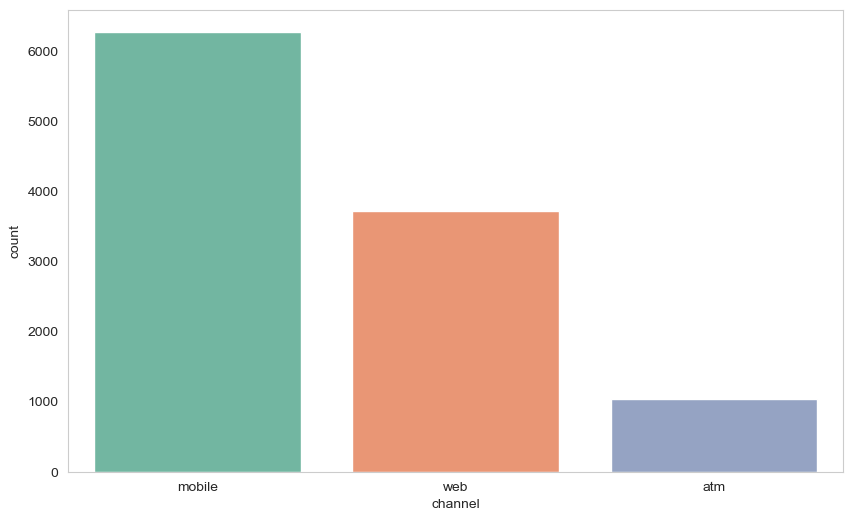

In [282]:
 #### channel with highest fruad rate
sns.countplot(
    x="channel",
    data=df,
    order=df["channel"].value_counts().index,    palette="Set2")
plt.grid(False)
plt.show()

 #### charge back rate

<Axes: xlabel='chargeback_history_count', ylabel='count'>

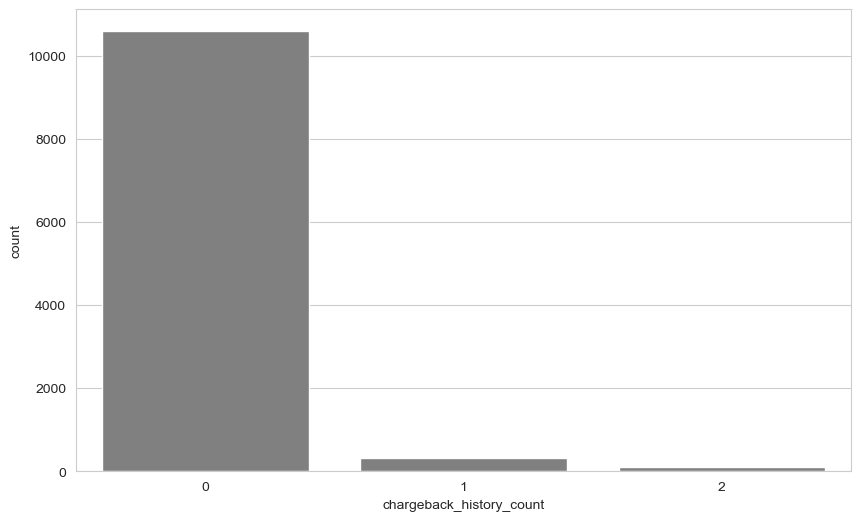

In [283]:
sns.countplot(
    x="chargeback_history_count",
    data=df,
order=df["chargeback_history_count"].value_counts(). index,color="grey")

#### country most targetted

<Axes: xlabel='home_country', ylabel='count'>

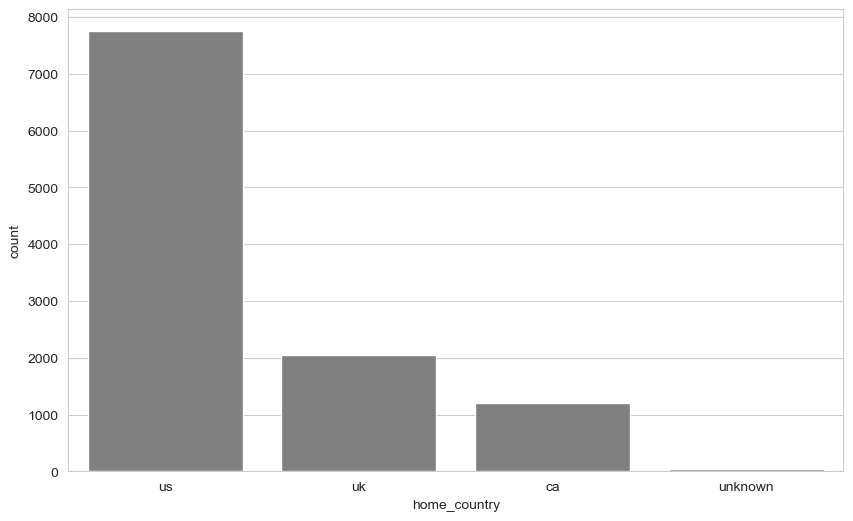

In [284]:
sns.countplot(
    x="home_country",
    data=df,
order=df["home_country"].value_counts(). index,color="grey")

#### most targetted currency

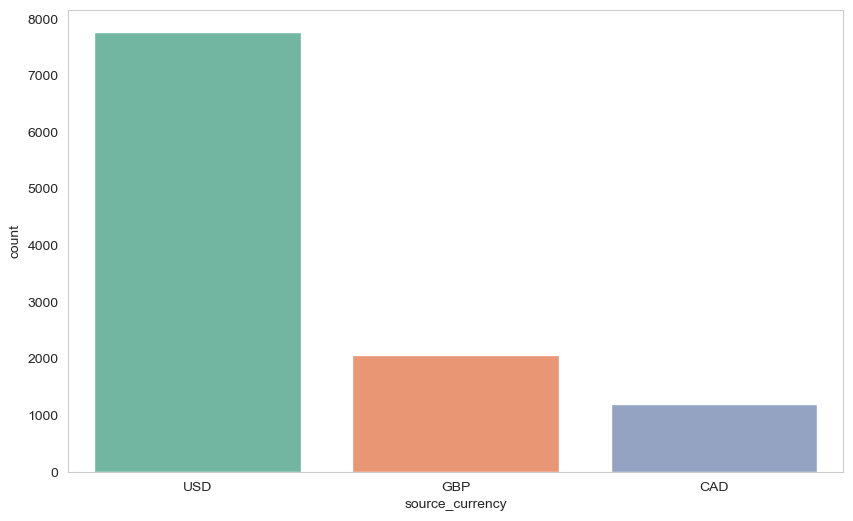

In [285]:
sns.countplot(
    x="source_currency",
    data=df,
    order=df["source_currency"].value_counts().index,    palette="Set2")
plt.grid(False)
plt.show()

#### destination currency

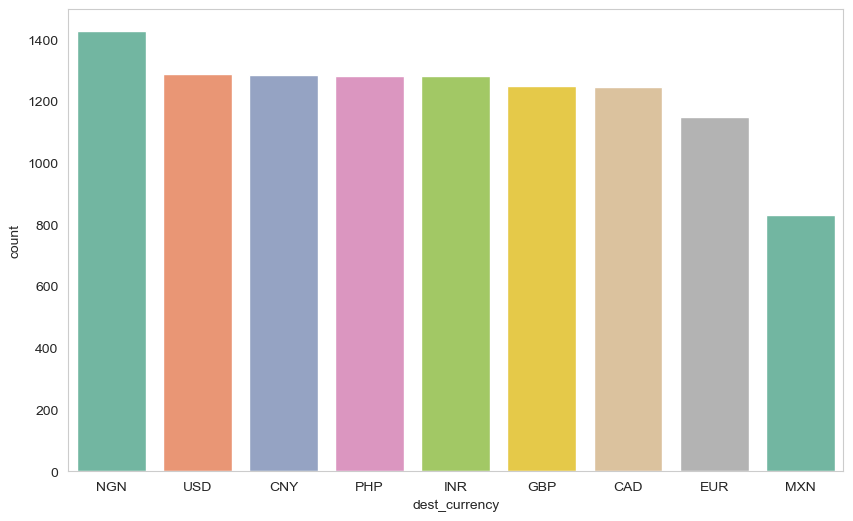

In [286]:
sns.countplot(
    x="dest_currency",
    data=df,
    order=df["dest_currency"].value_counts().index,    palette="Set2")
plt.grid(False)
plt.show()

 #### fraud peak hour

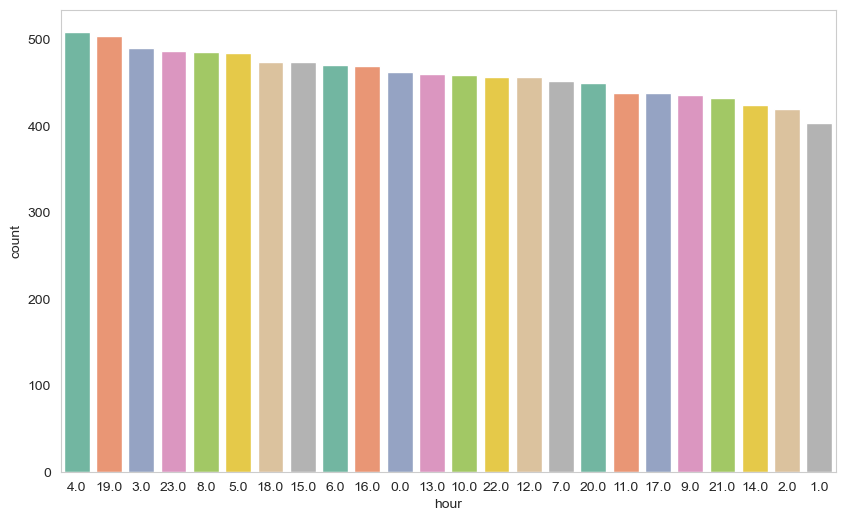

In [287]:
sns.countplot(
    x="hour",
    data=df,
    order=df["hour"].value_counts().index,    palette="Set2")
plt.grid(False)
plt.show()

In [288]:
fraud_currency = df.groupby("dest_currency")["amount_usd"].sum().reset_index()
fraud_currency

,dest_currency,amount_usd
0,CAD,592591.94
1,CNY,539117.76
2,EUR,509043.05
3,GBP,484442.91
4,INR,585978.72
5,MXN,380384.11
6,NGN,801908.55
7,PHP,575963.68
8,USD,513364.82


#### yearly fraud trent

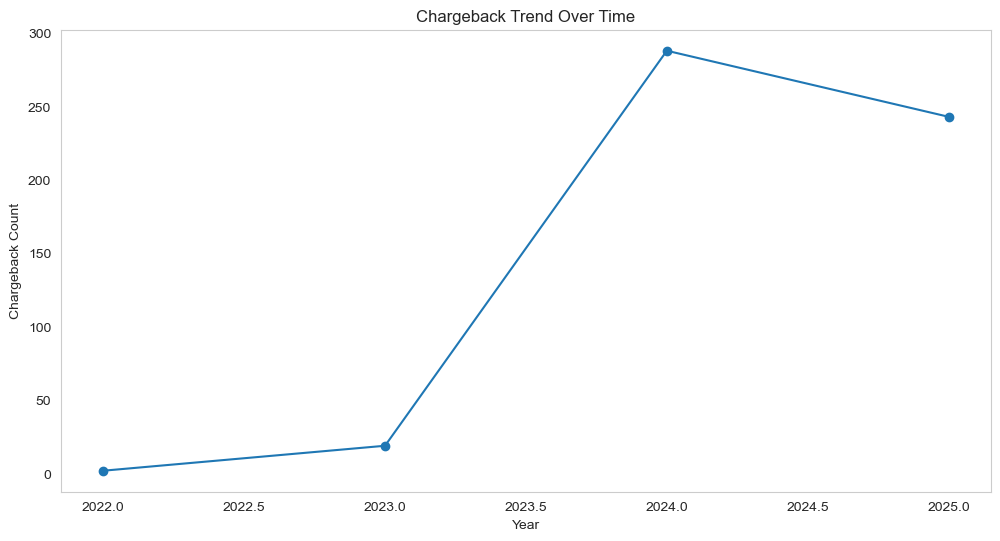

In [289]:
## monthly fruad tredn
chargeback = (
    df.groupby("year")["chargeback_history_count"]
      .sum()
      .reset_index())

plt.figure(figsize=(12,6))

plt.plot(
    chargeback["year"],
    chargeback["chargeback_history_count"],
    marker='o')

plt.title("Chargeback Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Chargeback Count")
plt.grid(False)

plt.show()

 #### fraud hourly peaks....

hour
0.0     0.062771
1.0     0.064516
2.0     0.078571
3.0     0.124490
4.0     0.184676
5.0     0.159091
6.0     0.210638
7.0     0.181416
8.0     0.125773
9.0     0.045872
10.0    0.069717
11.0    0.077626
12.0    0.061269
13.0    0.065217
14.0    0.077830
15.0    0.059072
16.0    0.063966
17.0    0.050228
18.0    0.078059
19.0    0.045635
20.0    0.060000
21.0    0.078704
22.0    0.056893
23.0    0.043121
Name: is_fraud, dtype: float64


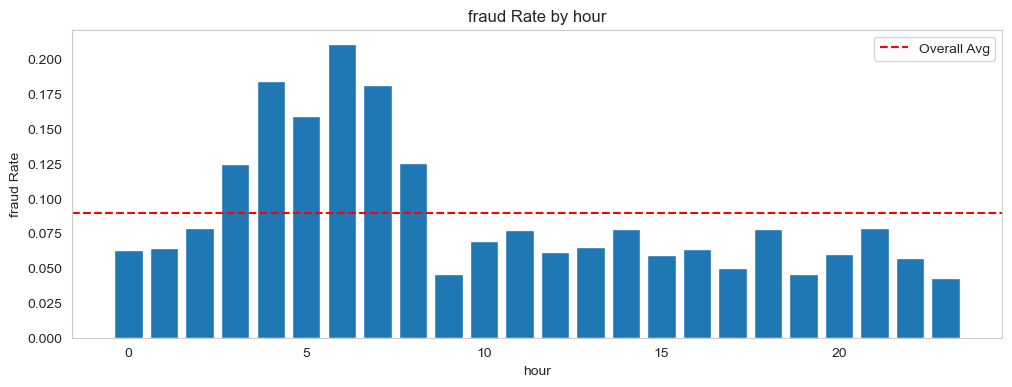

In [290]:
## fraud  hourly Rate this code helps to identify peak time for fruad
fraud_by_hour = df.groupby("hour")["is_fraud"].mean()

print(fraud_by_hour)

plt.figure(figsize=(12,4))
plt.bar(fraud_by_hour.index,fraud_by_hour.values)
plt.xlabel("hour")
plt.ylabel("fraud Rate")
plt.title("fraud Rate by hour")
plt.axhline(y=df["is_fraud"].mean(),color='red',linestyle='--', label='Overall Avg')
plt.grid(False)
plt.legend()
plt.show()

### fraud peak time in 24hrs

txn_velocity_24h
0     0.017819
1     0.016787
2     0.000000
3     0.042254
4     0.576642
5     0.780488
6     0.793651
7     0.814815
8     0.730539
9     0.964286
10    1.000000
11    1.000000
Name: is_fraud, dtype: float64


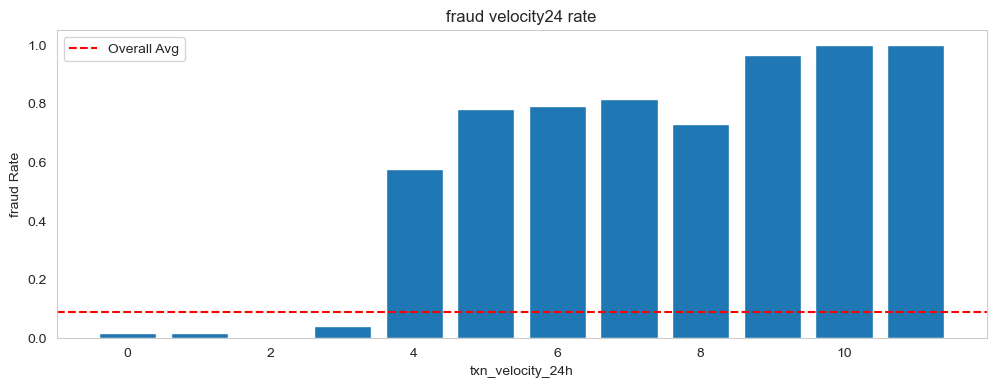

In [291]:
fraud_velocity_24hr = df.groupby("txn_velocity_24h")["is_fraud"].mean()

print(fraud_velocity_24hr)

plt.figure(figsize=(12,4))
plt.bar(fraud_velocity_24hr.index,fraud_velocity_24hr.values)
plt.xlabel("txn_velocity_24h")
plt.ylabel("fraud Rate")
plt.title("fraud velocity24 rate")
plt.axhline(y=df["is_fraud"].mean(),color='red',linestyle='--', label='Overall Avg')
plt.grid(False)
plt.legend()
plt.show()

txn_velocity_1h
-1    0.020619
 0    0.017560
 1    0.000000
 2    0.000000
 3    0.835878
 4    0.842324
 5    0.801047
 6    0.700000
 7    0.702703
 8    0.477273
Name: is_fraud, dtype: float64


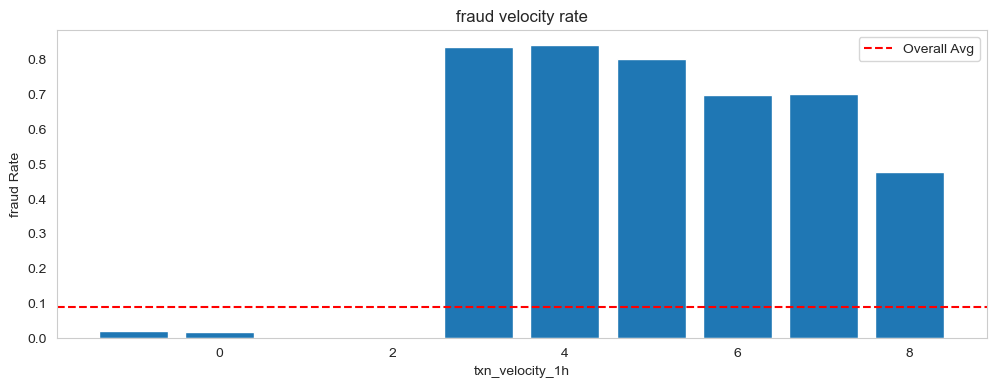

In [292]:
## fraud by velocity in 1hr
fraud_velocity_1hr = df.groupby("txn_velocity_1h")["is_fraud"].mean()

print(fraud_velocity_1hr)

plt.figure(figsize=(12,4))
plt.bar(fraud_velocity_1hr. index,fraud_velocity_1hr.values)
plt.xlabel("txn_velocity_1h")
plt.ylabel("fraud Rate")
plt.title("fraud velocity rate")
plt.axhline(y=df["is_fraud"].mean(),color='red',linestyle='--', label='Overall Avg')
plt.grid(False)
plt.legend()
plt.show()

age_bucket
<30d        0.360577
30-90d      0.440758
90-180d     0.023092
180-365d    0.016527
>1yr        0.010541
Name: is_fraud, dtype: float64


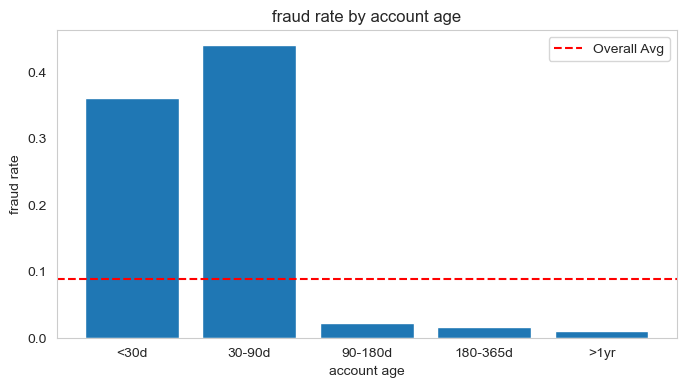

In [293]:
#fraud by account age

df["age_bucket"] = pd.cut(df["account_age_days"],
                          bins=[0,30,90,180,365,2000],
                          labels=["<30d", "30-90d", "90-180d", "180-365d", ">1yr"])
fraud_by_age = df.groupby("age_bucket")["is_fraud"].mean()
print(fraud_by_age )

plt.figure(figsize=(8,4))
plt.bar(range(len(fraud_by_age)),fraud_by_age.values)  
plt.xticks(range(len(fraud_by_age)),fraud_by_age.index)  
plt.xlabel("account age")
plt.ylabel("fraud rate")    
plt.title("fraud rate by account age")
plt.axhline(y=df["is_fraud"].mean(),color='red',linestyle='--', label='Overall Avg')

plt.grid(False)
plt.legend()
plt.show()

amount_bucket
<$100      0.018170
100-500    0.060671
$500-1k    0.295203
$1k-2k     0.669173
$2k-5k     0.943820
>$k5       0.138393
Name: is_fraud, dtype: float64


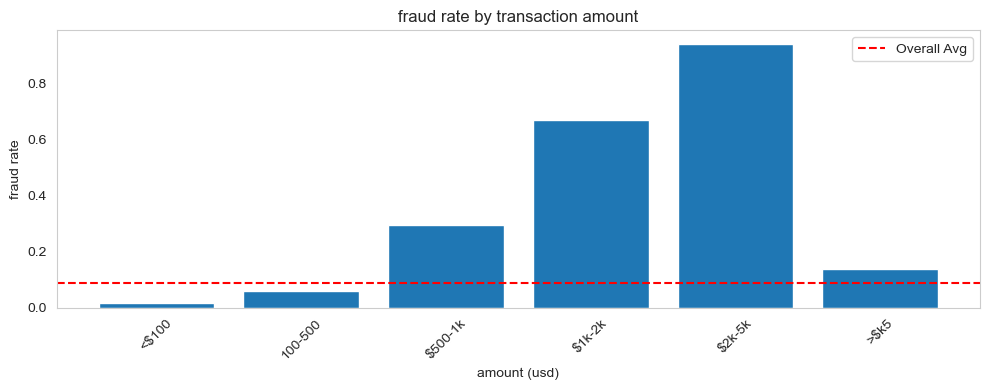

In [294]:
## fraud by transcation amount....

df["amount_bucket"] = pd.cut(df["amount_usd"],
                          bins=[0,100, 500, 1000, 2000, 5000, 20000],
                          labels=["<$100", "100-500", "$500-1k", "$1k-2k", "$2k-5k", ">$k5"])
fraud_by_amount = df.groupby("amount_bucket")["is_fraud"].mean()
print(fraud_by_amount )

plt.figure(figsize=(10,4))
plt.bar(range(len(fraud_by_amount)),fraud_by_amount.values)  
plt.xticks(range(len(fraud_by_amount)),fraud_by_amount.index, rotation=45)  
plt.xlabel("amount (usd)")
plt.ylabel("fraud rate")    
plt.title("fraud rate by transaction amount")
plt.axhline(y=df["is_fraud"].mean(),color='red',linestyle='--', label='Overall Avg')

plt.grid(False)
plt.legend()
plt.tight_layout()
plt.show()

ip_risk_bucket
Low<0.3     0.014922
0.3-0.5     0.022358
0.5-0.6     0.025956
0.6-0.7     0.036810
0.7-0.8     0.191489
High>0.8    0.625202
Name: is_fraud, dtype: float64


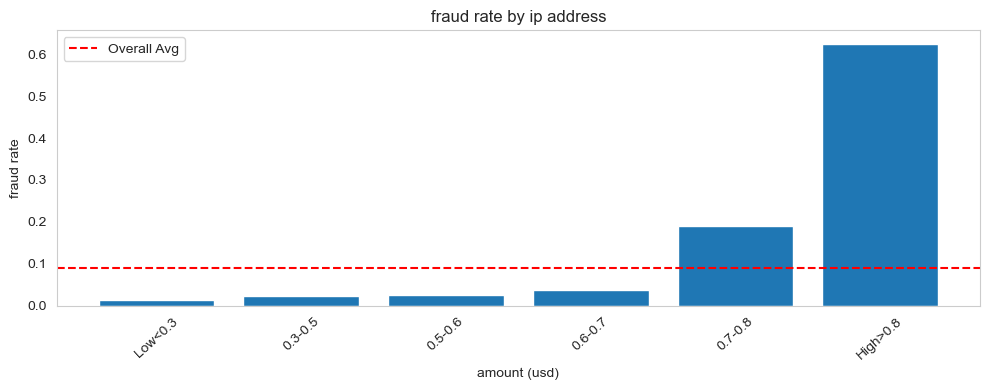

In [307]:
###fraud rate by ip address
df["ip_risk_bucket"] = pd.cut(df["ip_risk_score"],
                          bins=[0, 0.3, 0.5, 0.6, 0.7, 0.8, 1.0],
                          labels=["Low<0.3", "0.3-0.5", "0.5-0.6", "0.6-0.7", "0.7-0.8", "High>0.8"])
fraud_ip_risk = df.groupby("ip_risk_bucket")["is_fraud"].mean()
print(fraud_ip_risk )

plt.figure(figsize=(10,4))
plt.bar(range(len(fraud_ip_risk)),fraud_ip_risk.values)  
plt.xticks(range(len(fraud_ip_risk)), fraud_ip_risk.index, rotation=42) 
plt.xlabel("amount (usd)")
plt.ylabel("fraud rate")    
plt.title("fraud rate by ip address")
plt.axhline(y=df["is_fraud"].mean(),color='red',linestyle='--', label='Overall Avg')

plt.grid(False)
plt.legend()
plt.tight_layout()
plt.show()

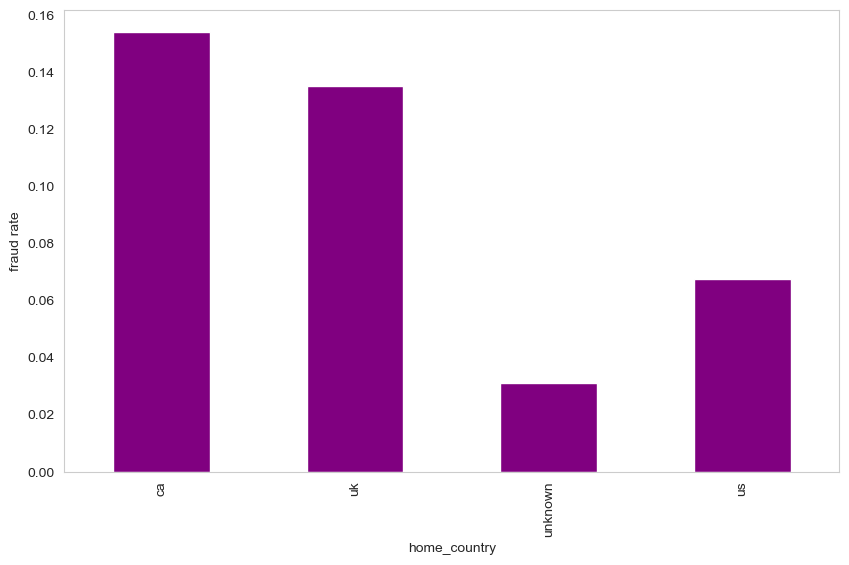

In [295]:
df.groupby("home_country")["is_fraud"].mean().plot.bar(color="purple")
plt.ylabel("fraud rate")
plt.xlabel("home_country")
plt.grid(False)
plt.show()

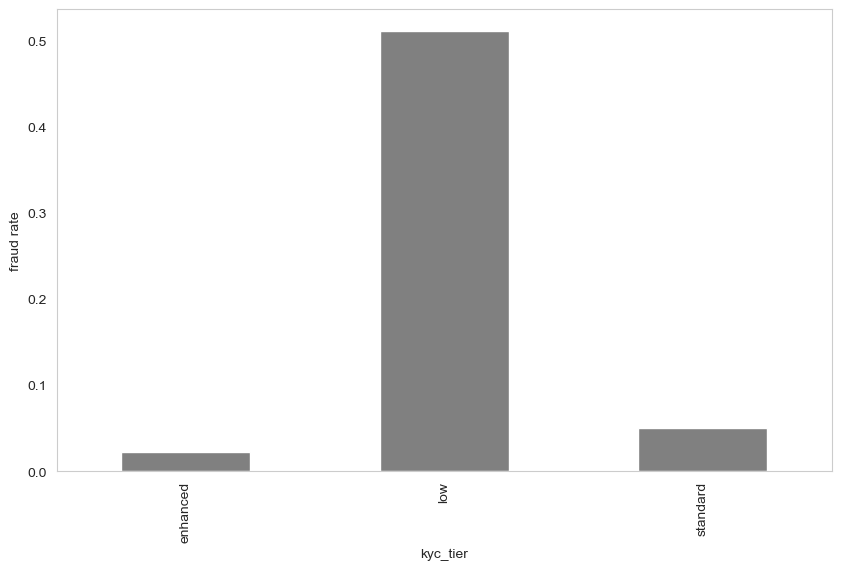

In [296]:
df.groupby("kyc_tier")["is_fraud"].mean().plot.bar(color="grey")
plt.ylabel("fraud rate")
plt.xlabel("kyc_tier")
plt.grid(False)
plt.show()

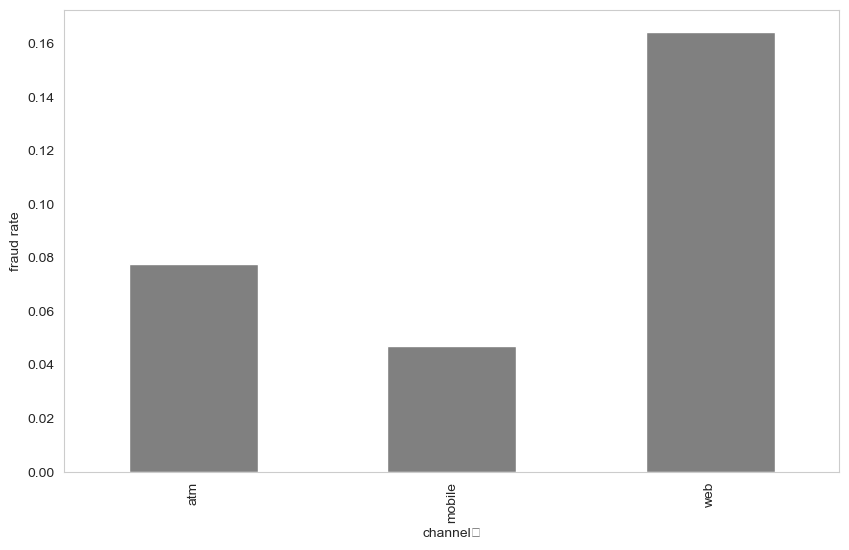

In [297]:
df.groupby("channel")["is_fraud"].mean().plot.bar(color="grey")
plt.ylabel("fraud rate")
plt.xlabel("channel	")
plt.grid(False)
plt.show()

In [298]:
df.head(2)

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,year,month,day,hour,day_of_week,is_weekend,age_bucket,amount_bucket
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,us,USD,CAD,atm,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0,2022.0,10.0,3.0,18.0,0.0,0,180-365d,100-500
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,ca,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0,2022.0,10.0,3.0,20.0,0.0,0,>1yr,100-500


In [299]:
channel_means = df.groupby("channel")["is_fraud"].count()
print(channel_means)

channel
atm       1033
mobile    6277
web       3724
Name: is_fraud, dtype: int64


In [300]:
avg_risk_score = df.groupby("is_fraud")["ip_risk_score"]. median()
print(avg_risk_score)

is_fraud
0    0.306
1    1.000
Name: ip_risk_score, dtype: float64


In [301]:
avg_device_trust = df.groupby("is_fraud")["device_trust_score"]. median()
print(avg_device_trust)

is_fraud
0    0.777
1    0.237
Name: device_trust_score, dtype: float64


#### fraud location mismatch

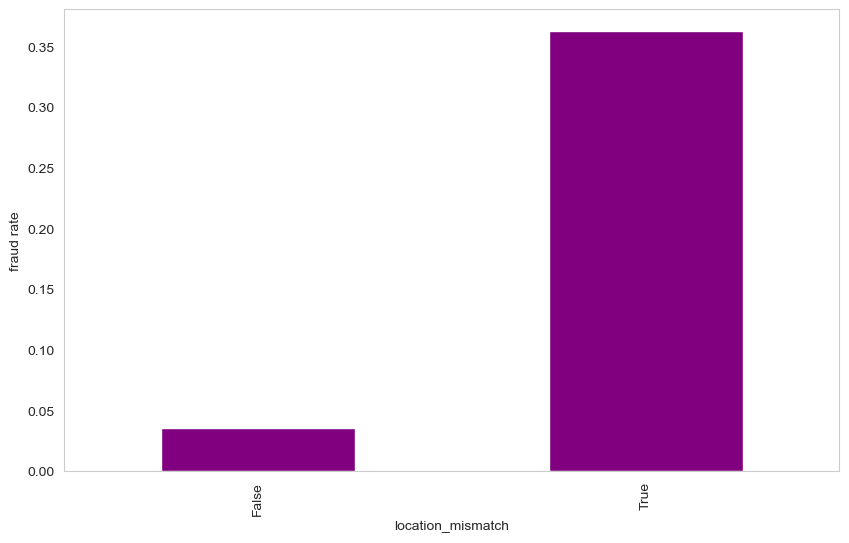

In [302]:
df.groupby("location_mismatch")["is_fraud"].mean().plot.bar(color="purple")
plt.ylabel("fraud rate")
plt.xlabel("location_mismatch")
plt.grid(False)
plt.show()

#### correleation metrics this will metrics is important for this project as it help  me decide whic columns have
#### correlation with the target feauture

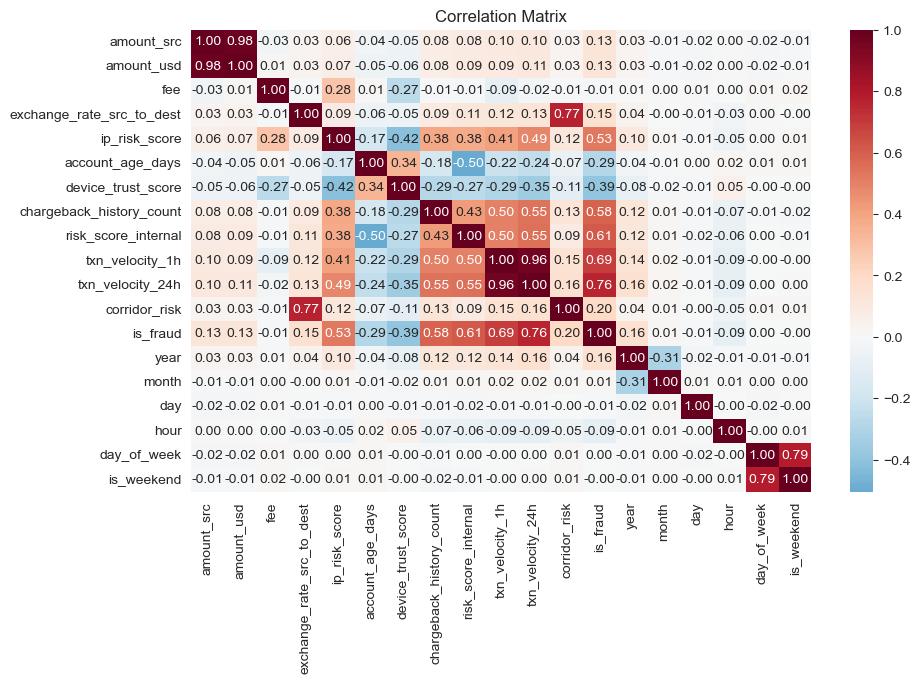

In [303]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

In [304]:
from sklearn.preprocessing import LabelEncoder



encoder = LabelEncoder()

In [305]:
 encoder = LabelEncoder()

In [308]:
df["home_country"] = encoder.fit_transform(df["home_country"])
df["source_currency"] = encoder.fit_transform(df["source_currency"])
df["dest_currency"] = encoder.fit_transform(df["dest_currency"])
df["channel"] = encoder.fit_transform(df["channel"])
df["new_device"] = encoder.fit_transform(df["new_device"])
df["ip_country"] = encoder.fit_transform(df["ip_country"])
df["location_mismatch"] = encoder.fit_transform(df["location_mismatch"])
df["kyc_tier"] = encoder.fit_transform(df["kyc_tier"])
df["ip_risk_bucket"] = encoder.fit_transform(df["ip_risk_bucket"])
df["age_bucket"] = encoder.fit_transform(df["age_bucket"])


In [242]:
df. head(2)

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,age_bucket,ip_risk_bucket
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,3,2,0,0,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,0,221.78.171.180,7,0,0.123,2,263,0.522,0,0.223,0,0,0.0,0,0,5
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,0,0,5,2,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,1,120.12.20.29,4,0,0.569,2,947,0.475,0,0.268,0,1,0.0,0,4,1


In [309]:
####  scaling

In [310]:
Number_cols_scale = [
    "amount_usd",
    "fee",
    "exchange_rate_src_to_dest",
    "ip_risk_score",
    "account_age_days",
    "device_trust_score",
    "chargeback_history_count",
    "risk_score_internal",
    "txn_velocity_1h",
    "txn_velocity_24h",
    "corridor_risk",
    "amount_src"]

#### scaling the data puts all variables on a comparable scale.

In [311]:
from sklearn.preprocessing import StandardScaler

In [312]:
scaler = StandardScaler()

In [313]:
df[Number_cols_scale] = scaler.fit_transform(df[Number_cols_scale])

In [314]:
df.head(2)

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,year,month,day,hour,day_of_week,is_weekend,age_bucket,amount_bucket,ip_risk_bucket
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,3,2,0,0,-0.117380,-0.123703,-0.099176,-0.434908,9f292dcc-3297-4947-a260-6a1ef69041ff,0,221.78.171.180,5,0,-1.012579,2,-0.380006,-0.485541,-0.19235,-0.312924,-0.305147,-0.373396,-0.536661,0,2022.0,10.0,3.0,18.0,0.0,0,0,100-500,5
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,0,0,5,2,-0.167772,-0.212096,-0.099187,-0.405073,3a95b9f5-309f-4684-a46d-e2ff2435bf78,1,120.12.20.29,3,0,0.631111,2,1.619903,-0.658110,-0.19235,-0.000334,-0.305147,0.131327,-0.536661,0,2022.0,10.0,3.0,20.0,0.0,0,4,100-500,1


In [315]:
!pip install imbalanced_learn

In [316]:
from imblearn.over_sampling import SMOTE

#### separating data

In [317]:
### seperating the target features
x = df.drop(columns=[ "transaction_id","customer_id","device_id","year","is_fraud", "amount_bucket","timestamp","ip_address","fee",], axis=1)
y = df["is_fraud"]

In [318]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: is_fraud, dtype: int64

In [319]:
smote = SMOTE(random_state=42)

In [320]:
x_resample, y_resample = smote.fit_resample(x, y)

In [321]:
x_resample.head()

,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,exchange_rate_src_to_dest,new_device,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,month,day,hour,day_of_week,is_weekend,age_bucket,ip_risk_bucket
0,3,2,0,0,-0.117380,-0.123703,-0.434908,0,5,0,-1.012579,2,-0.380006,-0.485541,-0.19235,-0.312924,-0.305147,-0.373396,-0.536661,10.0,3.0,18.0,0.0,0,0,5
1,0,0,5,2,-0.167772,-0.212096,-0.405073,1,3,0,0.631111,2,1.619903,-0.658110,-0.19235,-0.000334,-0.305147,0.131327,-0.536661,10.0,3.0,20.0,0.0,0,4,1
2,3,2,1,1,-0.202615,-0.207787,-0.419761,0,5,0,0.144638,0,-0.075926,1.045552,-0.19235,-0.639408,-0.305147,-0.373396,-0.536661,10.0,3.0,23.0,0.0,0,4,0
3,3,2,2,1,-0.275599,-0.279785,-0.436021,0,5,0,0.723246,2,-0.719171,-0.379062,-0.19235,0.854081,-0.305147,-0.373396,-0.536661,10.0,4.0,1.0,1.0,0,2,1
4,3,2,4,1,-0.173232,-0.178801,-0.220492,0,5,0,-1.019950,0,-0.397549,0.880326,-0.19235,-0.076745,-0.305147,-0.373396,-0.536661,10.0,4.0,9.0,1.0,0,0,5


In [322]:
y_resample.value_counts()

is_fraud
0    10047
1    10047
Name: count, dtype: int64

In [323]:
y_resample.value_counts(normalize=True)*100

is_fraud
0    50.0
1    50.0
Name: proportion, dtype: float64

In [324]:
df = pd.DataFrame(x_resample, columns=x.columns)

In [325]:
df["is_fraud"] = y_resample

In [326]:
y_resample.value_counts()

is_fraud
0    10047
1    10047
Name: count, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split

In [327]:
x_train, x_test, y_train, y_test = train_test_split(x_resample, y_resample, test_size=0.2,random_state=42)

In [328]:
print(f"training size {len(x_train)}")
print(f"testing size {len(x_test)}")

training size 16075
testing size 4019


In [329]:
y_train.value_counts(normalize=True)*100

is_fraud
0    50.00311
1    49.99689
Name: proportion, dtype: float64

In [330]:
from sklearn.linear_model import LogisticRegression

In [331]:
lr_model = LogisticRegression(random_state=42, class_weight="balanced")

In [332]:
lr_model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [333]:
y_pred = lr_model.predict(x_test)

In [334]:
print(y_pred)

[1 0 0 ... 0 0 1]


In [335]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: is_fraud, dtype: int64

In [336]:
from sklearn.metrics import confusion_matrix, classification_report

report = classification_report(y_test, y_pred)
matrix = confusion_matrix(y_test, y_pred)

print("LogisticRegression")
print(report)
print(matrix)

LogisticRegression
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      2009
           1       0.96      0.88      0.92      2010

    accuracy                           0.93      4019
   macro avg       0.93      0.93      0.93      4019
weighted avg       0.93      0.93      0.93      4019

[[1943   66]
 [ 234 1776]]


In [337]:
from sklearn.ensemble import RandomForestClassifier

In [338]:
rf_model = RandomForestClassifier(random_state=42,class_weight="balanced")

In [339]:
rf_model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [340]:
y_pred = rf_model.predict(x_test)

In [342]:
y_pred

array([1, 0, 0, ..., 0, 0, 1], shape=(4019,))

In [343]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: is_fraud, dtype: int64

In [344]:
report = classification_report(y_test, y_pred)
matrix = confusion_matrix(y_test, y_pred)

print("Random Forest Classifier Report")
print(report)

Random Forest Classifier Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2009
           1       1.00      0.98      0.99      2010

    accuracy                           0.99      4019
   macro avg       0.99      0.99      0.99      4019
weighted avg       0.99      0.99      0.99      4019



In [345]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [346]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(random_state=42,class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "SVM": SVC(random_state=42, class_weight="balanced"),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "xgboost":XGBClassifier()}


In [347]:
models.items()

dict_items([('Logistic Regression', LogisticRegression(class_weight='balanced', random_state=42)), ('Random Forest', RandomForestClassifier(class_weight='balanced', random_state=42)), ('Gradient Boosting', GradientBoostingClassifier(random_state=42)), ('AdaBoost', AdaBoostClassifier(random_state=42)), ('SVM', SVC(class_weight='balanced', random_state=42)), ('KNN', KNeighborsClassifier()), ('Decision Tree', DecisionTreeClassifier(random_state=42)), ('xgboost', XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=N

training Logistic Regression....
Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      2009
           1       0.96      0.88      0.92      2010

    accuracy                           0.93      4019
   macro avg       0.93      0.93      0.93      4019
weighted avg       0.93      0.93      0.93      4019



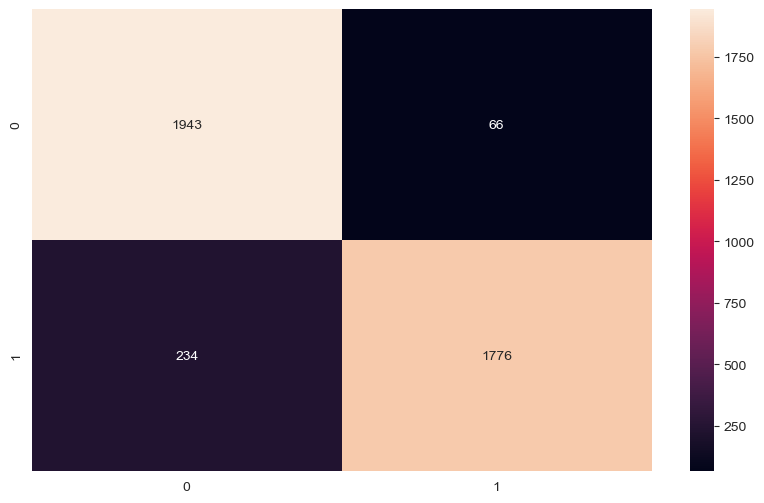

training Random Forest....
Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2009
           1       1.00      0.98      0.99      2010

    accuracy                           0.99      4019
   macro avg       0.99      0.99      0.99      4019
weighted avg       0.99      0.99      0.99      4019



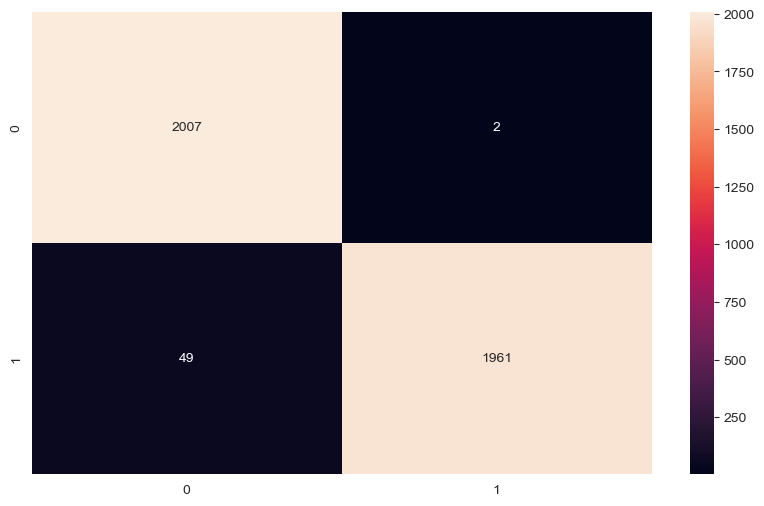

training Gradient Boosting....
Gradient Boosting Classification Report
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      2009
           1       1.00      0.95      0.97      2010

    accuracy                           0.97      4019
   macro avg       0.97      0.97      0.97      4019
weighted avg       0.97      0.97      0.97      4019



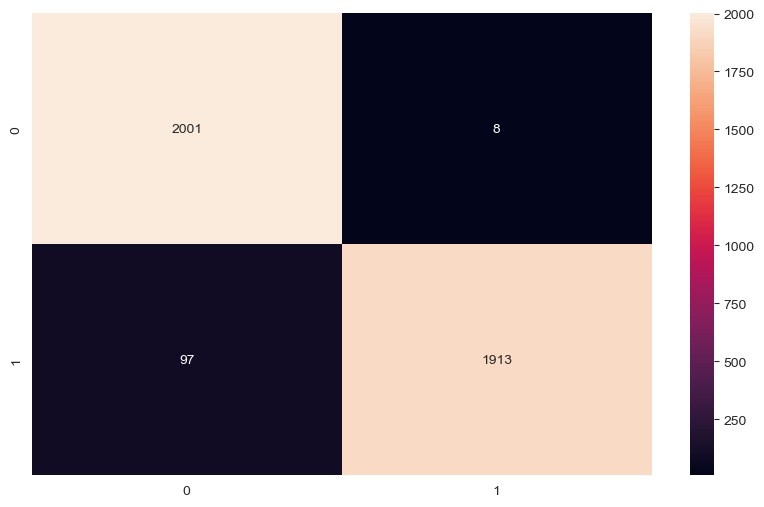

training AdaBoost....
AdaBoost Classification Report
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      2009
           1       0.97      0.92      0.95      2010

    accuracy                           0.95      4019
   macro avg       0.95      0.95      0.95      4019
weighted avg       0.95      0.95      0.95      4019



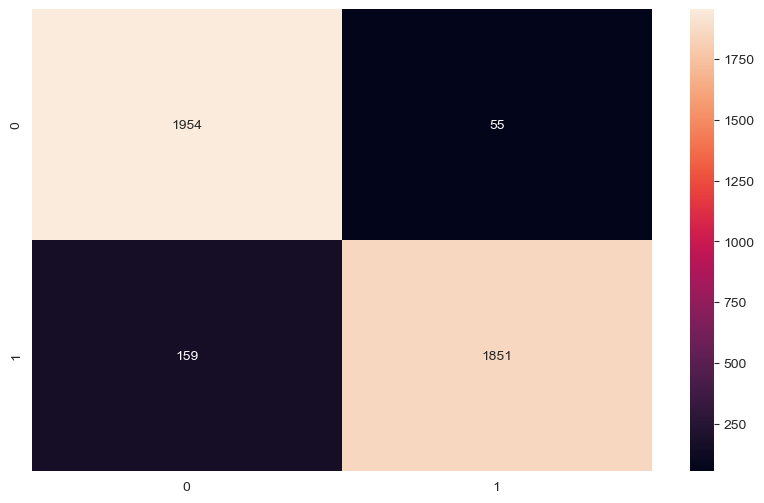

training SVM....
SVM Classification Report
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      2009
           1       0.99      0.85      0.92      2010

    accuracy                           0.92      4019
   macro avg       0.93      0.92      0.92      4019
weighted avg       0.93      0.92      0.92      4019



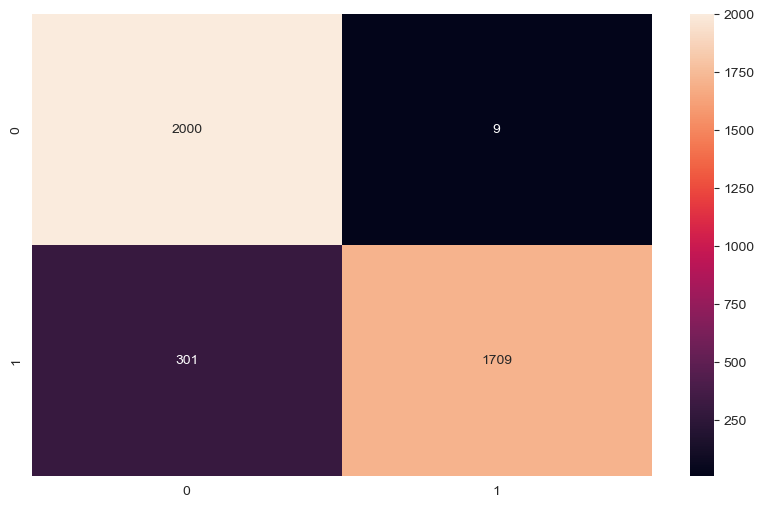

training KNN....
KNN Classification Report
              precision    recall  f1-score   support

           0       1.00      0.92      0.96      2009
           1       0.93      1.00      0.96      2010

    accuracy                           0.96      4019
   macro avg       0.96      0.96      0.96      4019
weighted avg       0.96      0.96      0.96      4019



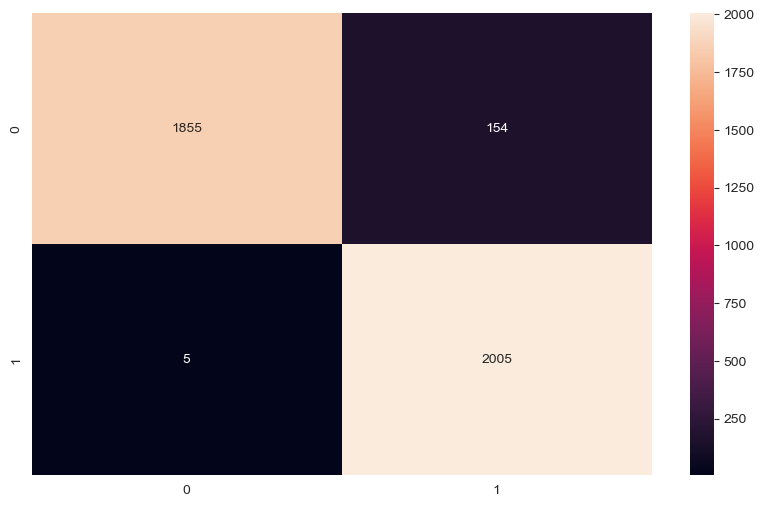

training Decision Tree....
Decision Tree Classification Report
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2009
           1       0.97      0.97      0.97      2010

    accuracy                           0.97      4019
   macro avg       0.97      0.97      0.97      4019
weighted avg       0.97      0.97      0.97      4019



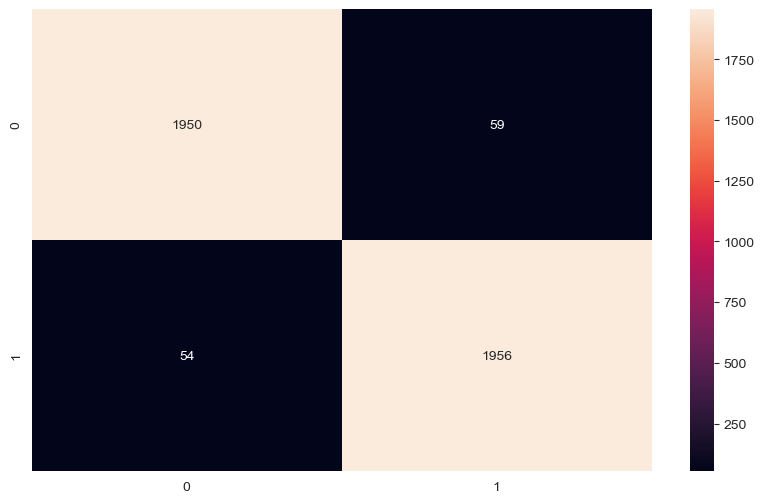

training xgboost....
xgboost Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2009
           1       1.00      0.98      0.99      2010

    accuracy                           0.99      4019
   macro avg       0.99      0.99      0.99      4019
weighted avg       0.99      0.99      0.99      4019



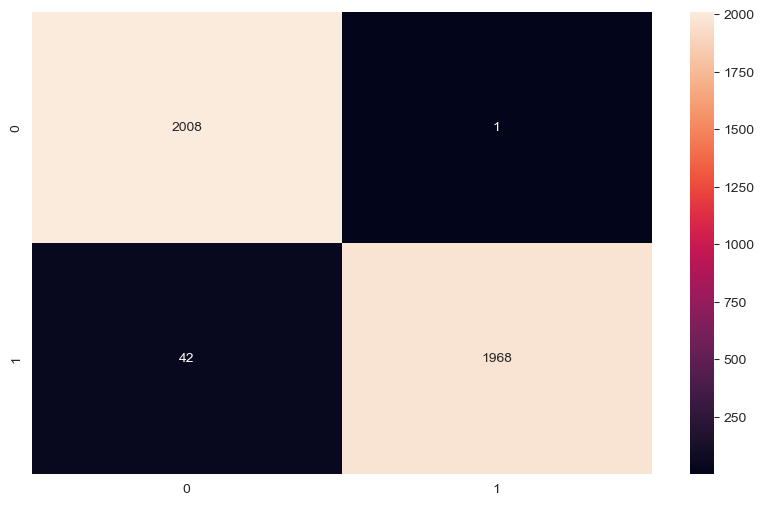

In [348]:
results = {}
for model_name, model in models.items():
    print(f"training {model_name}....")
    #training the model
    model.fit(x_train, y_train)
    
    # predicting model
    y_pred = model.predict(x_test)
    
    #evaluating the model
    accuracy = accuracy_score(y_test,y_pred)
    report = classification_report(y_test, y_pred)
    matrix = confusion_matrix(y_test, y_pred)

    # Store results
    results[model_name] = {
        'accuracy': accuracy,
        'classification_report': report,
        'confusion_matrix': matrix
    }
    print(f"{model_name} Classification Report")
    print(report)
    sns.heatmap(matrix, annot=True, fmt="g")
    plt.show()

In [349]:
from sklearn.model_selection import GridSearchCV

In [350]:
RandomForestClassifier(random_state=42,class_weight="balanced")

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [359]:
parameter_grid = {
    "n_estimators": [50,100, 200],
    "max_depth": [None,10,20,30],
    "min_samples_split": [2, 5 ,10],
    "min_samples_leaf": [1, 2,4]}

In [360]:
grid_search = GridSearchCV(RandomForestClassifier(random_state=42,class_weight="balanced"),
                           param_grid = parameter_grid,
                           scoring = "f1",
                           cv=5,
                           n_jobs=-1)

In [361]:
grid_search.fit(x_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [357]:
print(f"Best Hyperparameters: {grid_search.best_params_}")

Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [362]:
best_rf = grid_search.best_estimator_

In [363]:
y_pred_best_rf = best_rf.predict(x_test)

In [364]:
print("fine tuned Random forest classifier")
report= classification_report(y_test, y_pred_best_rf)
print(report)

fine tuned Random forest classifier
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2009
           1       1.00      0.98      0.99      2010

    accuracy                           0.99      4019
   macro avg       0.99      0.99      0.99      4019
weighted avg       0.99      0.99      0.99      4019

